In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import re
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load data & run structural row cleaning
df = pd.read_csv('dataset.csv')
df['track_name_norm'] = df['track_name'].str.replace(r'\s*[\(\[][^\]\)]*[\)\]]', '', regex=True).str.strip().str.lower()
df['artists_norm'] = df['artists'].str.lower().str.strip()
df = df.drop_duplicates(subset=['track_name_norm', 'artists_norm'], keep='first')

best_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'loudness', 'speechiness', 'tempo', 'valence']

# 🔥 STEP 1: Define Macro-Genre Mapping Function
genre_map = {
    'metal': 'Metal', 'grindcore': 'Metal', 'black-metal': 'Metal', 'heavy-metal': 'Metal',
    'pop': 'Pop', 'indie-pop': 'Pop', 'k-pop': 'Pop', 'mandopop': 'Pop',
    'rock': 'Rock', 'hard-rock': 'Rock', 'punk-rock': 'Rock', 'psych-rock': 'Rock',
    'house': 'Electronic', 'techno': 'Electronic', 'trance': 'Electronic', 'edm': 'Electronic', 'idm': 'Electronic',
    'classical': 'Classical', 'opera': 'Classical',
    'indian': 'Indian', 'groove': 'Indian',
    'hip-hop': 'Hip-Hop', 'rap': 'Hip-Hop',
    'jazz': 'Jazz', 'blues': 'Jazz',
    'country': 'Country', 'bluegrass': 'Country',
    'reggae': 'Reggae', 'dubstep': 'Reggae',
    'folk': 'Folk', 'acoustic': 'Folk'
}

def map_to_macro_genre(micro_genre):
    if pd.isna(micro_genre):
        return 'Other'
    for keyword, macro in genre_map.items():
        if keyword in micro_genre.lower():
            return macro
    return 'Other'

# Apply target simplification mapping
df['macro_genre'] = df['track_genre'].apply(map_to_macro_genre)

# Change target column reference to macro_genre
target = 'macro_genre' 
df = df.dropna(subset=best_features + [target] + ['artists', 'track_genre'])

# Keep micro-genre inside text metadata so recommendation engine retains high precision
df['text_metadata'] = df['artists'].str.replace(';', ' ') + ' ' + df['track_genre']

# 2. Define feature categories for the pipeline
scale_features = ['tempo', 'loudness']
passthrough_features = [f for f in best_features if f not in scale_features]
text_feature = 'text_metadata'

# 3. Construct the Advanced Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', MinMaxScaler(), scale_features),
        ('passthrough', 'passthrough', passthrough_features),
        ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english'), text_feature)
    ],
    sparse_threshold=0 
)

# 4. Generate the hybrid mathematical matrix
X_hybrid = preprocessor.fit_transform(df)

# 5. Extract text feature column names to track the new matrix structure
tfidf_vocab = preprocessor.named_transformers_['tfidf'].get_feature_names_out()
all_engineered_features = scale_features + passthrough_features + list(tfidf_vocab)

# 6. Rebuild your structural DataFrame
df_cleaned = pd.DataFrame(X_hybrid, columns=all_engineered_features, index=df.index)
df_cleaned[target] = df[target]

print(f"Hybrid Pipeline executed. Vector space expanded to {df_cleaned.shape[1] - 1} mathematical dimensions.")
print(f"Target variable shifted to: '{target}'")

Hybrid Pipeline executed. Vector space expanded to 1008 mathematical dimensions.
Target variable shifted to: 'macro_genre'


# Exploratory Data Analysis:

In [12]:
print("Checking statistical distribution of features:")
df_cleaned.describe()

print("Checking distribution of target variable:")
print(df_cleaned[target].value_counts().head(10))

Checking statistical distribution of features:
Checking distribution of target variable:
macro_genre
Other         50215
Electronic     6898
Pop            6259
Metal          4693
Rock           4474
Folk           1667
Classical      1564
Country        1539
Indian         1274
Jazz            901
Name: count, dtype: int64


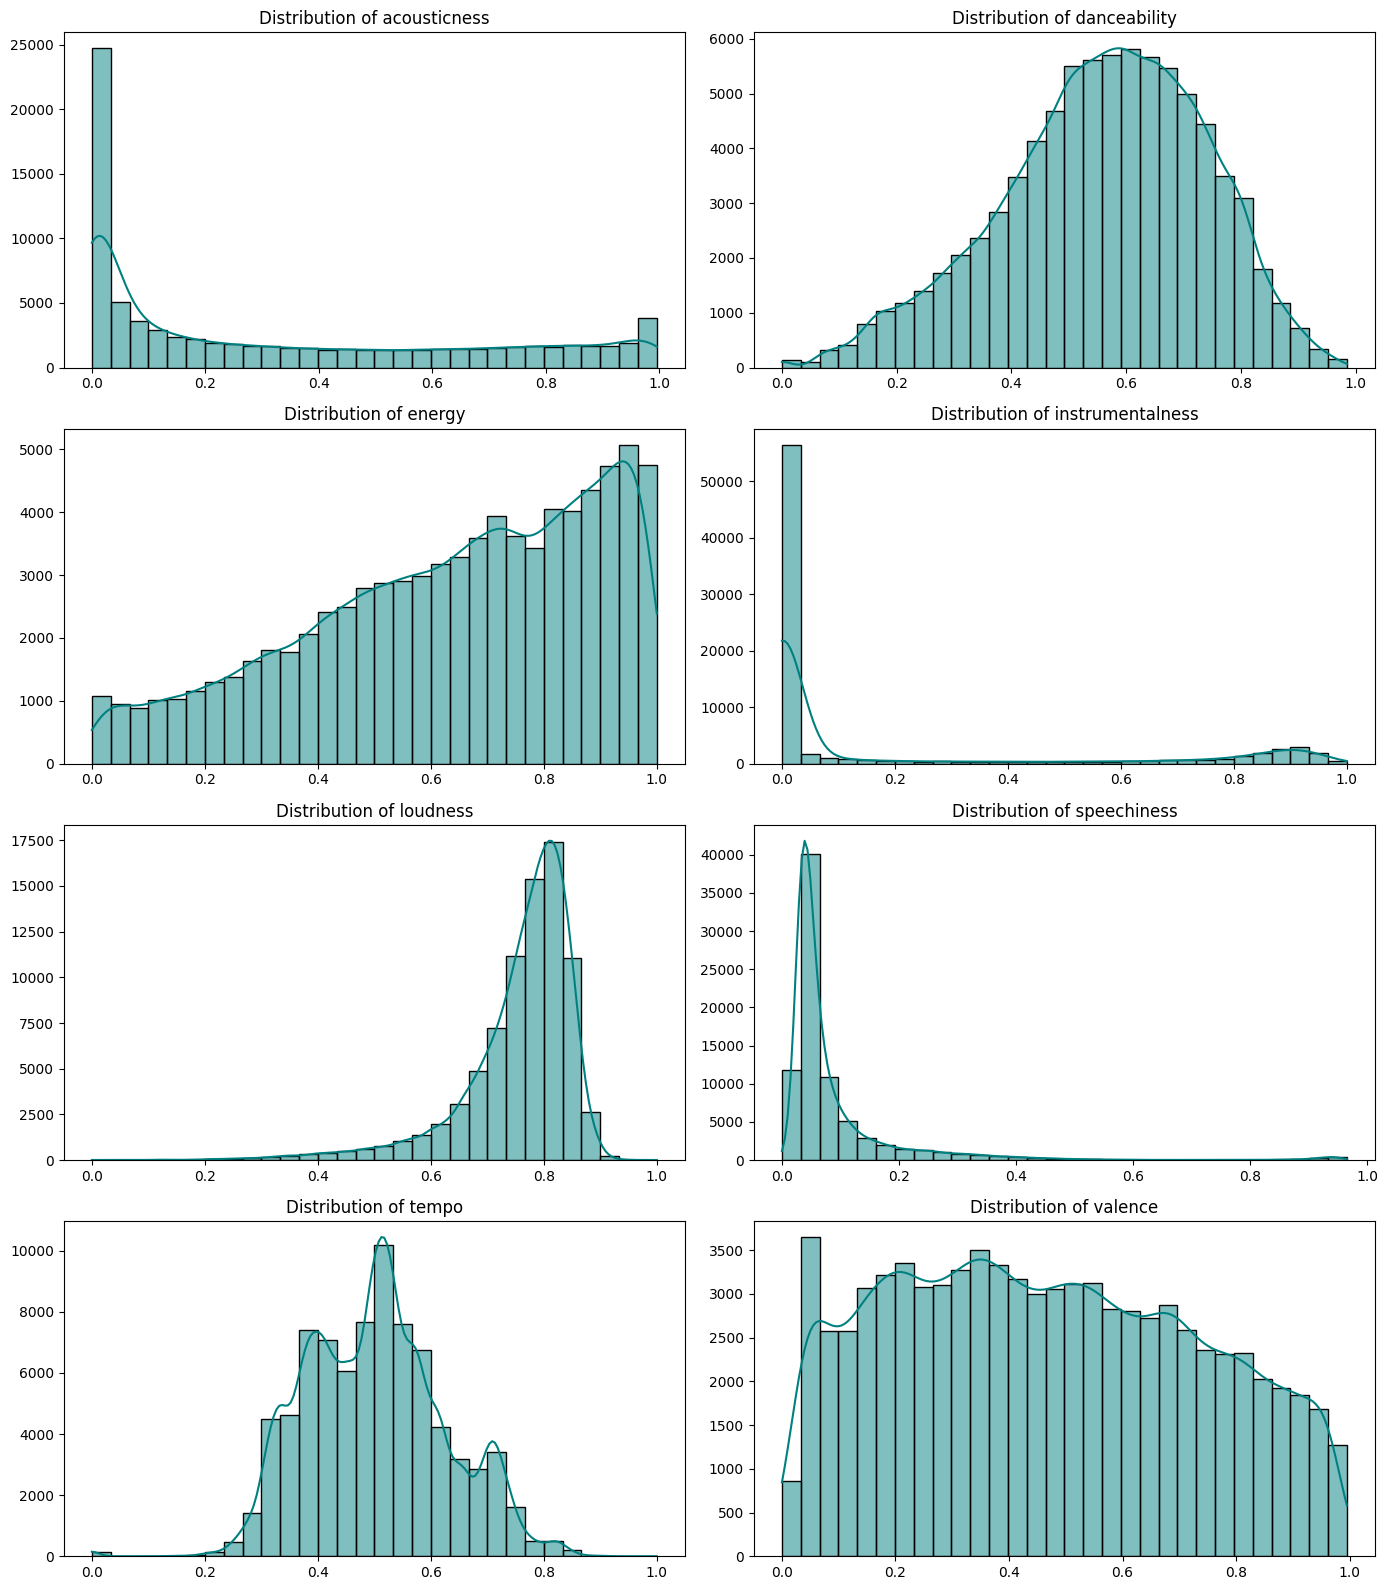

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the plotting grid
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

# Plot distributions for each numerical feature
for i, col in enumerate(best_features):
    sns.histplot(df_cleaned[col], bins=30, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Correlation Matrix to check for multicollinearity and relationships between features:

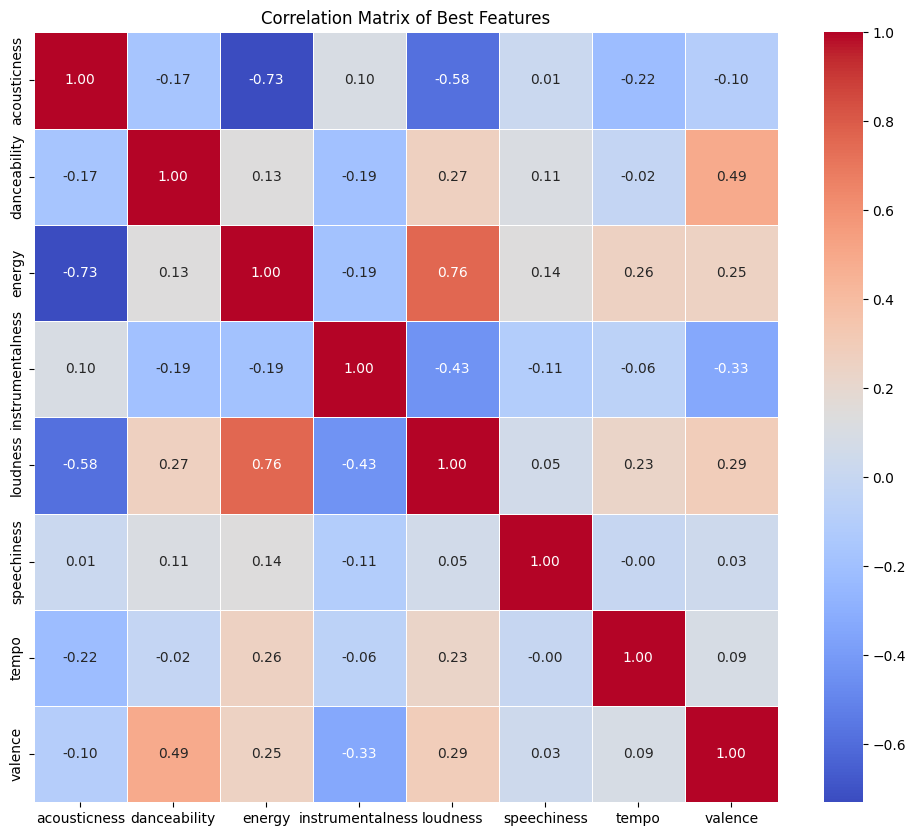

In [5]:
correlation_matrix = df_cleaned[best_features].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Best Features')

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_7048\766369176.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='macro_genre', y='energy', data=df_subset, palette='Set2')
C:\Users\hp\AppData\Local\Temp\ipykernel_7048\766369176.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='macro_genre', y='acousticness', data=df_subset, palette='Set2')


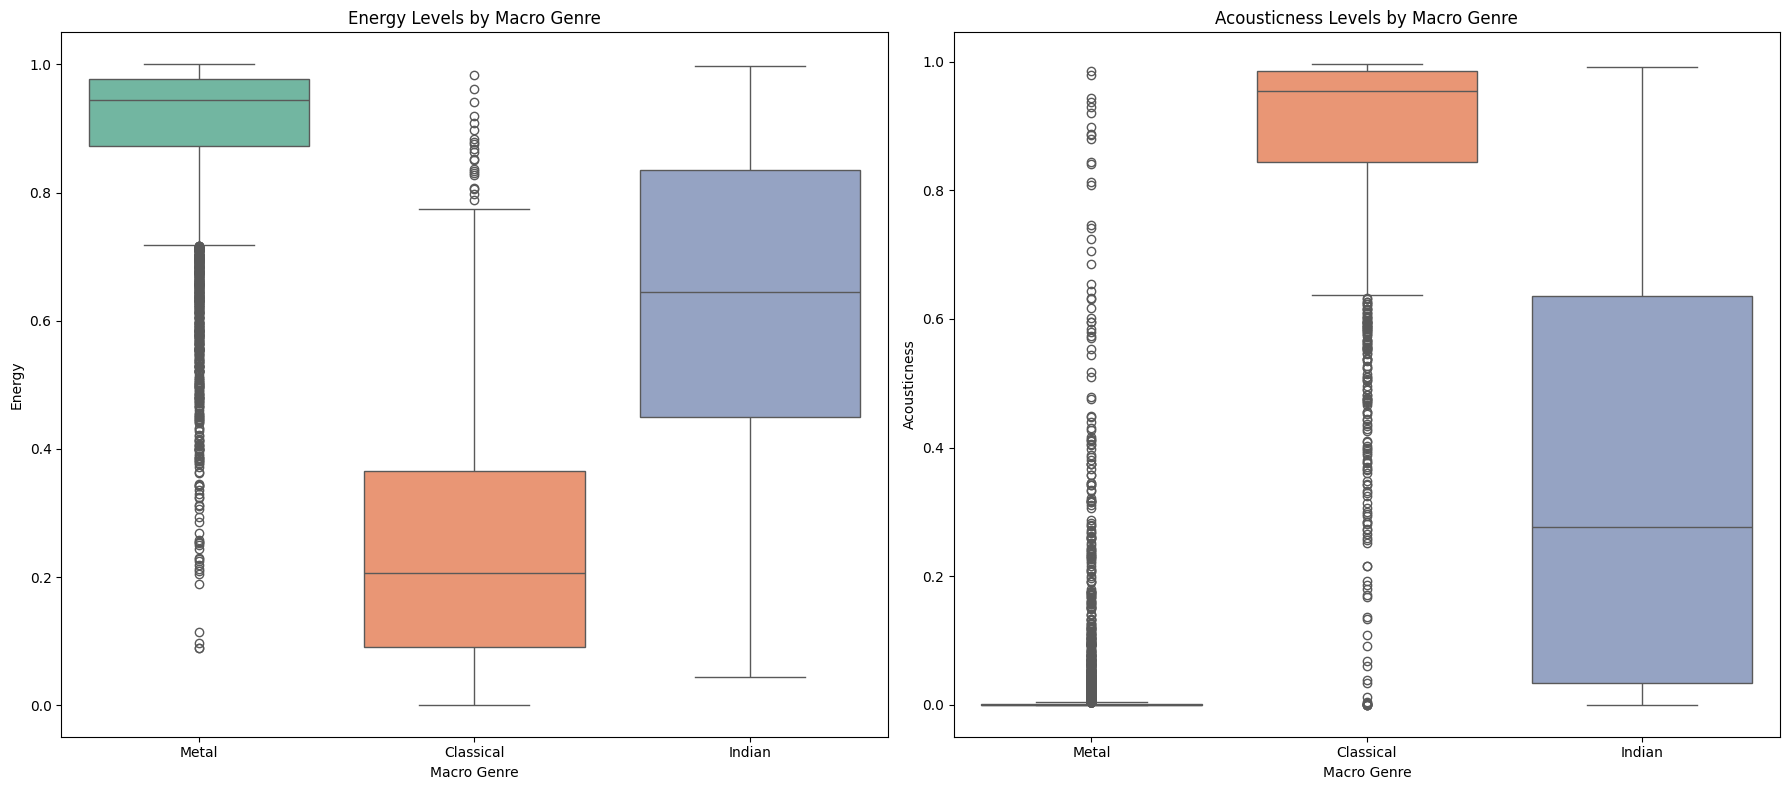

In [13]:
# 1. Filter our data down to just 3 highly distinct MACRO genres
target_genres = ['Indian', 'Classical', 'Metal']
df_subset = df_cleaned[df_cleaned['macro_genre'].isin(target_genres)]

# 2. Setup a 1-row, 2-column canvas
plt.figure(figsize=(18, 8))

# 3. Plot 1: Comparing Energy levels across these genres
plt.subplot(1, 2, 1)
sns.boxplot(x='macro_genre', y='energy', data=df_subset, palette='Set2')
plt.title('Energy Levels by Macro Genre')
plt.xlabel('Macro Genre')
plt.ylabel('Energy')

# 4. Plot 2: Comparing Acousticness levels across these genres
plt.subplot(1, 2, 2)
sns.boxplot(x='macro_genre', y='acousticness', data=df_subset, palette='Set2')
plt.title('Acousticness Levels by Macro Genre')
plt.xlabel('Macro Genre')
plt.ylabel('Acousticness')

# 5. Clean layout adjustments and render
plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)
X = df_cleaned[best_features]
y = df_cleaned['macro_genre'] # Linked to macro target

# 2. Encode text labels into numbers (0 to number of macro classes)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 3. Split into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Data split complete!")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Unique classes to predict: {len(label_encoder.classes_)}")

Data split complete!
Training features shape: (64492, 8)
Testing features shape: (16124, 8)
Unique classes to predict: 12


In [19]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score

# 1. Initialize the base classifier
xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    eval_metric='mlogloss',
    random_state=42
)

# 2. Define the hyperparameter search grid
param_dist = {
    'max_depth': [4, 6, 8, 10],            # Depth of the trees (controls overfitting)
    'learning_rate': [0.03, 0.07, 0.1, 0.15], # Step size shrinkage used to prevent overfitting
    'subsample': [0.7, 0.8, 0.9, 1.0],      # Subsample ratio of the training instances
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0], # Subsample ratio of columns when constructing each tree
    'min_child_weight': [1, 3, 5]          # Minimum sum of instance weight needed in a child
}

# 3. Setup the Randomized Search Engine
tuned_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,                             # Number of parameter settings sampled
    scoring='accuracy',
    cv=3,                                  # 3-Fold Cross-Validation
    random_state=42,
    n_jobs=-1,                             # Use all available CPU cores
    verbose=1
)

# 4. Execute the search on the training data
print("Starting Hyperparameter Tuning...")
tuned_search.fit(X_train, y_train)

# 5. Extract the best model configuration
best_model = tuned_search.best_estimator_

# 6. Evaluate accuracy on the unseen test dataset
y_pred_tuned = best_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("\n--- Tuning Complete ---")
print(f"Optimal Parameters Found: {tuned_search.best_params_}")
print(f"Upgraded Model Accuracy: {tuned_accuracy * 100:.2f}%")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Tuning Complete ---
Optimal Parameters Found: {'subsample': 0.7, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Upgraded Model Accuracy: 67.49%


C:\Users\hp\AppData\Local\Temp\ipykernel_7048\1876392699.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


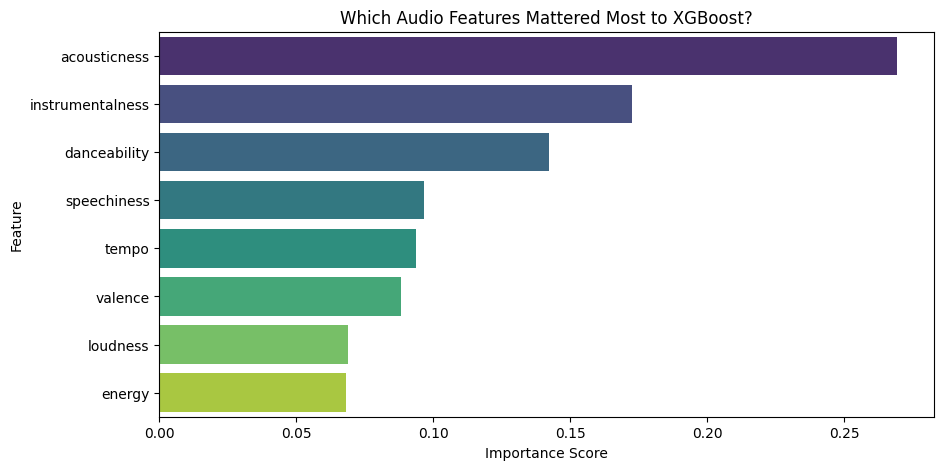

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get importance scores from the model
importance = model.feature_importances_

# 2. Pair them with column names and sort
feat_imp_df = pd.DataFrame({
    'Feature': best_features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# 3. Plot the data
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Which Audio Features Mattered Most to XGBoost?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## Implementing Cosine Similarity:

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

def get_hybrid_recommendations(song_name, num_recommendations=5):
    # 1. Locate search target
    search_name = re.sub(r'\s*[\(\[][^\]\)]*[\)\]]', '', song_name).strip().lower()
    matched_songs = df[df['track_name_norm'] == search_name]
    
    if matched_songs.empty:
        return f"Song '{song_name}' not found."
    
    target_idx = matched_songs.index[0]
    
    # 2. Extract hybrid audio + text feature vectors
    target_vector = df_cleaned.loc[[target_idx], all_engineered_features].values
    all_vectors = df_cleaned[all_engineered_features].values
    
    # 3. Process Cosine Similarity
    similarity_scores = cosine_similarity(target_vector, all_vectors).flatten()
    
    # 4. Map, drop self, and extract
    df_results = df.loc[df_cleaned.index].copy()
    df_results['similarity_score'] = similarity_scores
    df_results = df_results.drop(target_idx)
    
    top_matches = df_results.sort_values(by='similarity_score', ascending=False).head(num_recommendations)
    
    return top_matches[['track_name', 'artists', 'track_genre', 'similarity_score']]

# Test the upgraded hybrid system
get_hybrid_recommendations('Kesariya (From "Brahmastra")')

MemoryError: Unable to allocate 620. MiB for an array with shape (80616, 1008) and data type float64